In [3]:
import pandas as pd
data = pd.read_csv(r"C:\Users\KOURO\OneDrive\Desktop\TP\Titanic.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Afficher les 5 premières lignes
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Informations sur la structure du dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [6]:
# Statistiques descriptives pour les colonnes numériques
print(data.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
# Statistiques descriptives pour les colonnes catégorielles
print(data.describe(include='object'))

                           Name   Sex  Ticket    Cabin Embarked
count                       891   891     891      204      889
unique                      891     2     681      147        3
top     Braund, Mr. Owen Harris  male  347082  B96 B98        S
freq                          1   577       7        4      644


In [8]:
# Vérifier les valeurs manquantes
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
# Vérifier la dimension
print(data.shape)

(891, 12)


In [10]:
# Supprimer les doublons
data = data.drop_duplicates()

In [14]:
# Remplacer les valeurs manquantes
data['Age'].fillna(data['Age'].median(), inplace=True)   # âge median
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)  # valeur la plus fréquente

C:\Users\KOURO\AppData\Local\Temp\ipykernel_33252\1051272974.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)   # âge median
C:\Users\KOURO\AppData\Local\Temp\ipykernel_33252\1051272974.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [15]:
# Vérifier qu’il n’y a plus de valeurs manquantes
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [16]:
# Changer le type de variable si nécessaire
data['Pclass'] = data['Pclass'].astype('category')

In [17]:
# Compter les modalités
print(data['Sex'].value_counts())
print(data['Embarked'].value_counts())


Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [19]:
import seaborn as sns

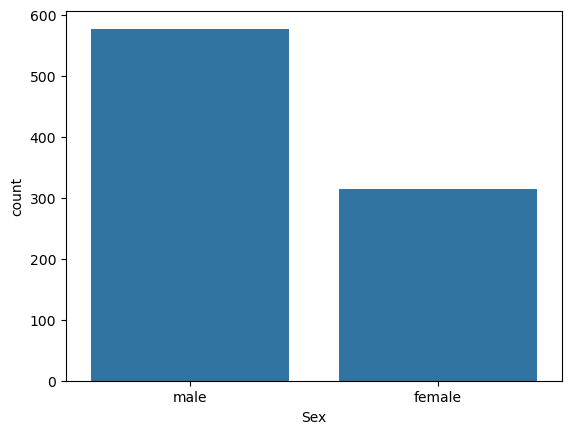

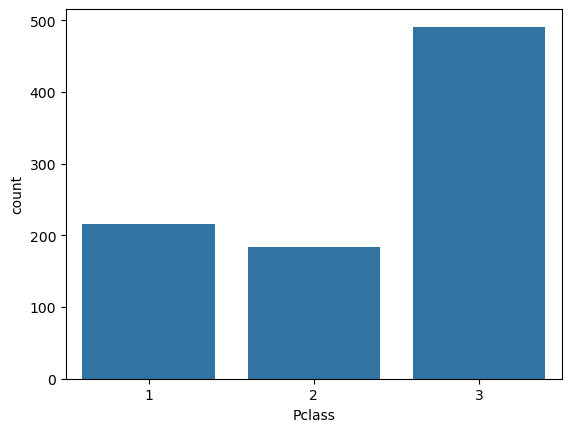

In [22]:
# Diagrammes
sns.countplot(x='Sex', data=data)
plt.show()

sns.countplot(x='Pclass', data=data)
plt.show()

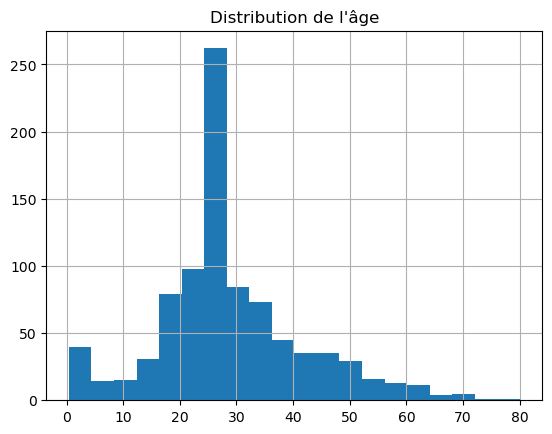

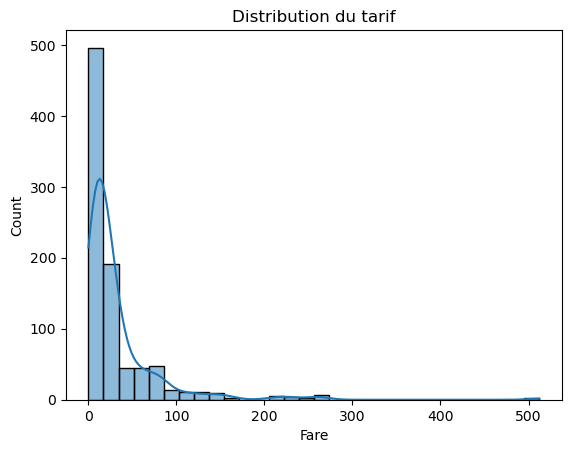

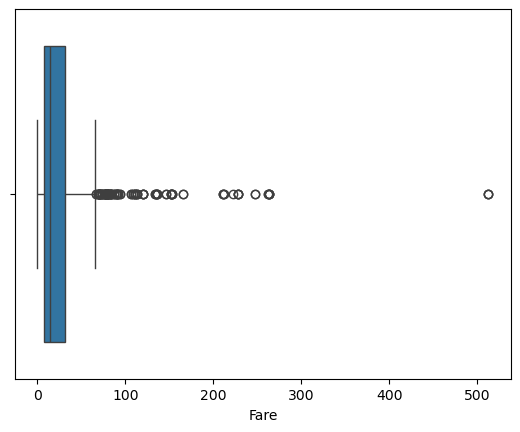

In [23]:
# Histogrammes
data['Age'].hist(bins=20)
plt.title("Distribution de l'âge")
plt.show()

sns.histplot(data['Fare'], bins=30, kde=True)
plt.title("Distribution du tarif")
plt.show()

# Boîtes à moustaches pour détecter les outliers
sns.boxplot(x='Fare', data=data)
plt.show()

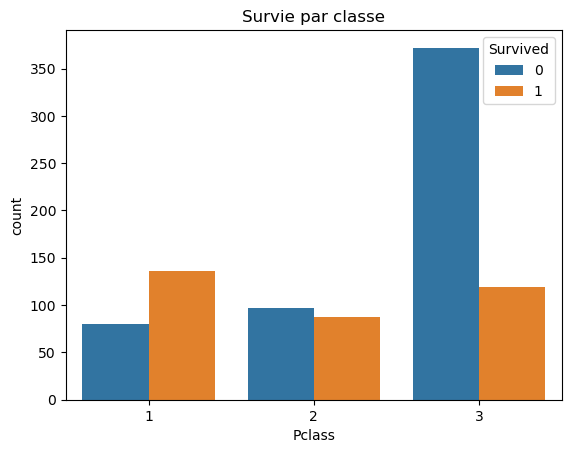

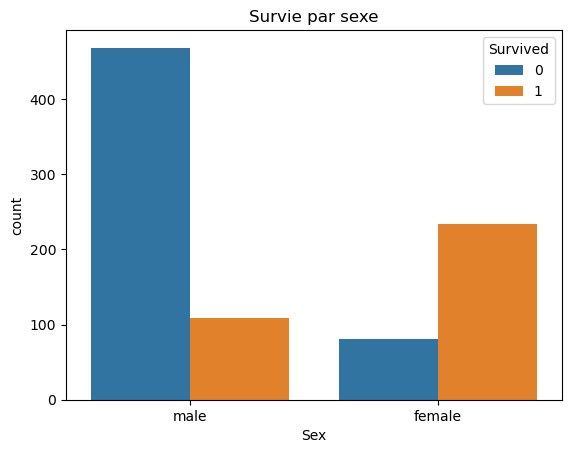

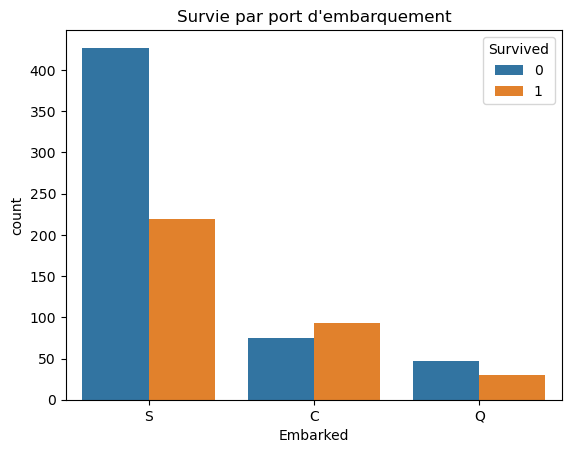

In [24]:
sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title("Survie par classe")
plt.show()

sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Survie par sexe")
plt.show()

sns.countplot(x='Embarked', hue='Survived', data=data)
plt.title("Survie par port d'embarquement")
plt.show()

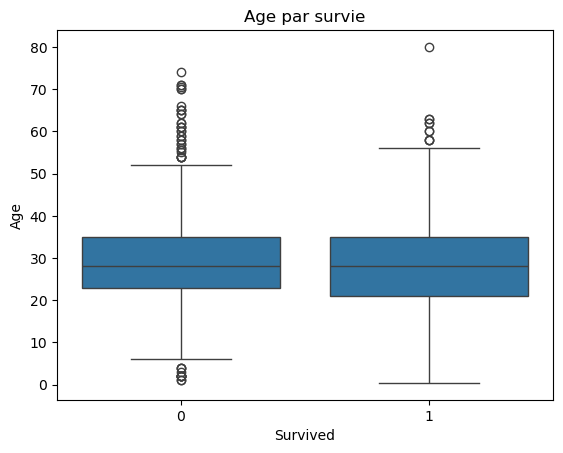

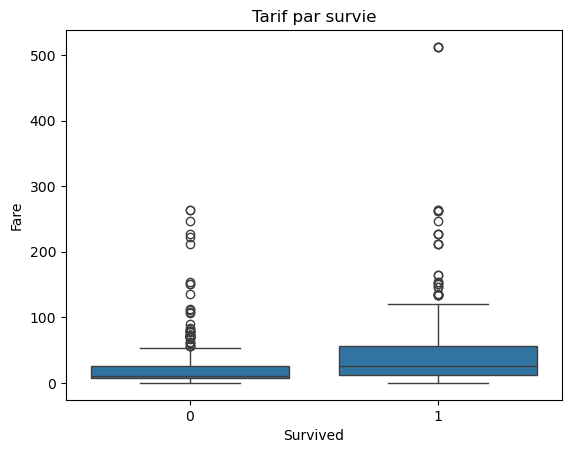

In [25]:
sns.boxplot(x='Survived', y='Age', data=data)
plt.title("Age par survie")
plt.show()

sns.boxplot(x='Survived', y='Fare', data=data)
plt.title("Tarif par survie")
plt.show()

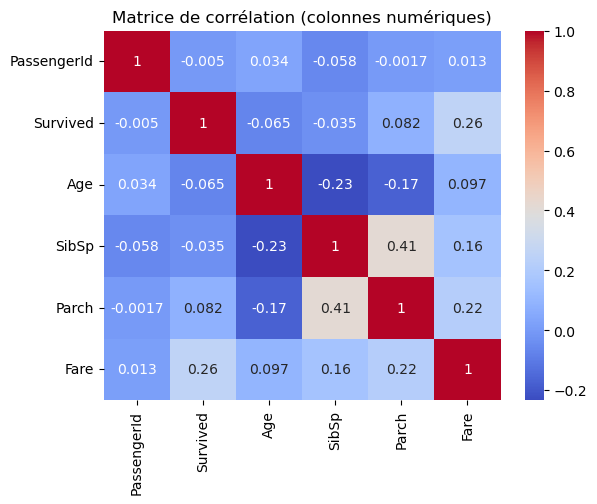

In [27]:
# Sélectionner les colonnes numériques
numeric_cols = data.select_dtypes(include=np.number)

# Calculer la corrélation
corr = numeric_cols.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation (colonnes numériques)")
plt.show()


In [28]:
# Colonnes numériques
print(data.select_dtypes(include=np.number).columns)

# Colonnes catégorielles
print(data.select_dtypes(include='object').columns)


Index(['PassengerId', 'Survived', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


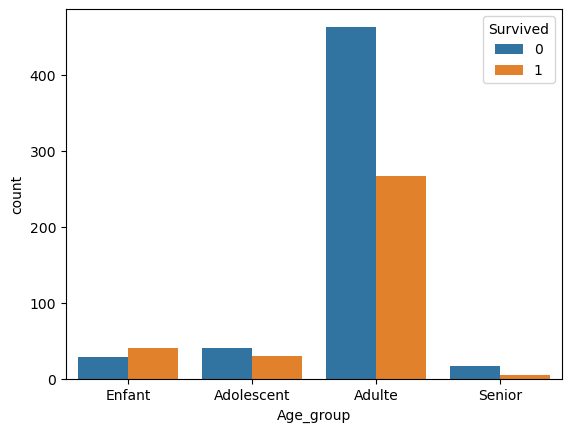

In [29]:
data['Age_group'] = pd.cut(data['Age'], bins=[0, 12, 18, 60, 100],
                           labels=['Enfant','Adolescent','Adulte','Senior'])

sns.countplot(x='Age_group', hue='Survived', data=data)
plt.show()


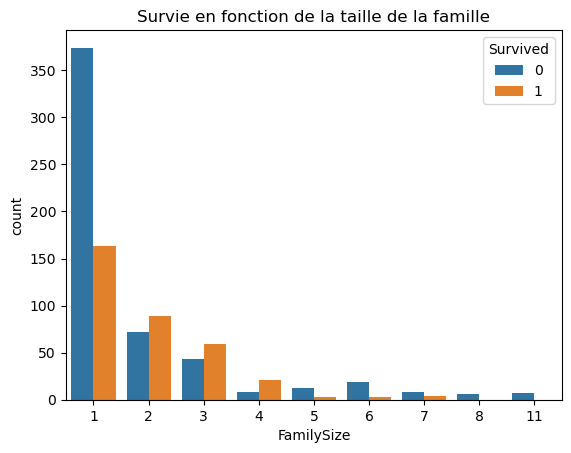

In [30]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
sns.countplot(x='FamilySize', hue='Survived', data=data)
plt.title("Survie en fonction de la taille de la famille")
plt.show()


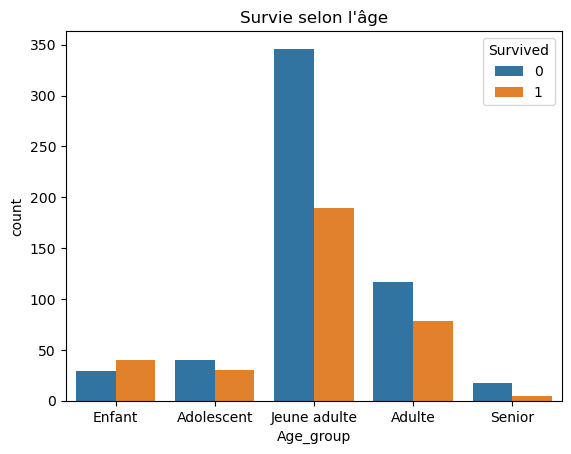

In [31]:
data['Age_group'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100],
                           labels=['Enfant','Adolescent','Jeune adulte','Adulte','Senior'])

sns.countplot(x='Age_group', hue='Survived', data=data)
plt.title("Survie selon l'âge")
plt.show()


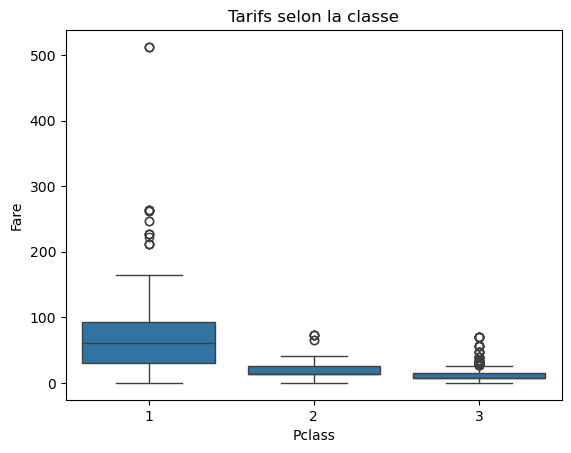

In [32]:
sns.boxplot(x='Pclass', y='Fare', data=data)
plt.title("Tarifs selon la classe")
plt.show()


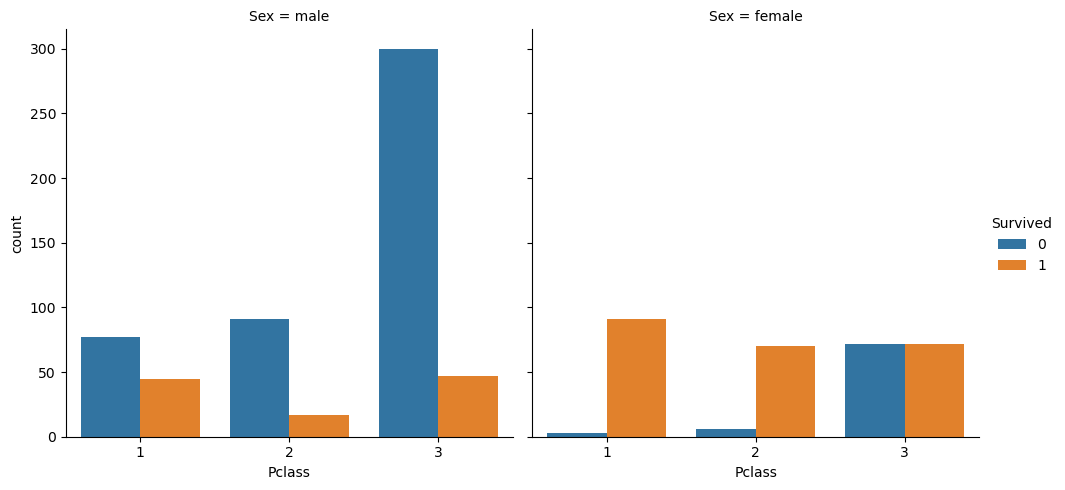

In [33]:
#Sexe + Classe vs Survie
sns.catplot(x='Pclass', hue='Survived', col='Sex', kind='count', data=data)
plt.show()


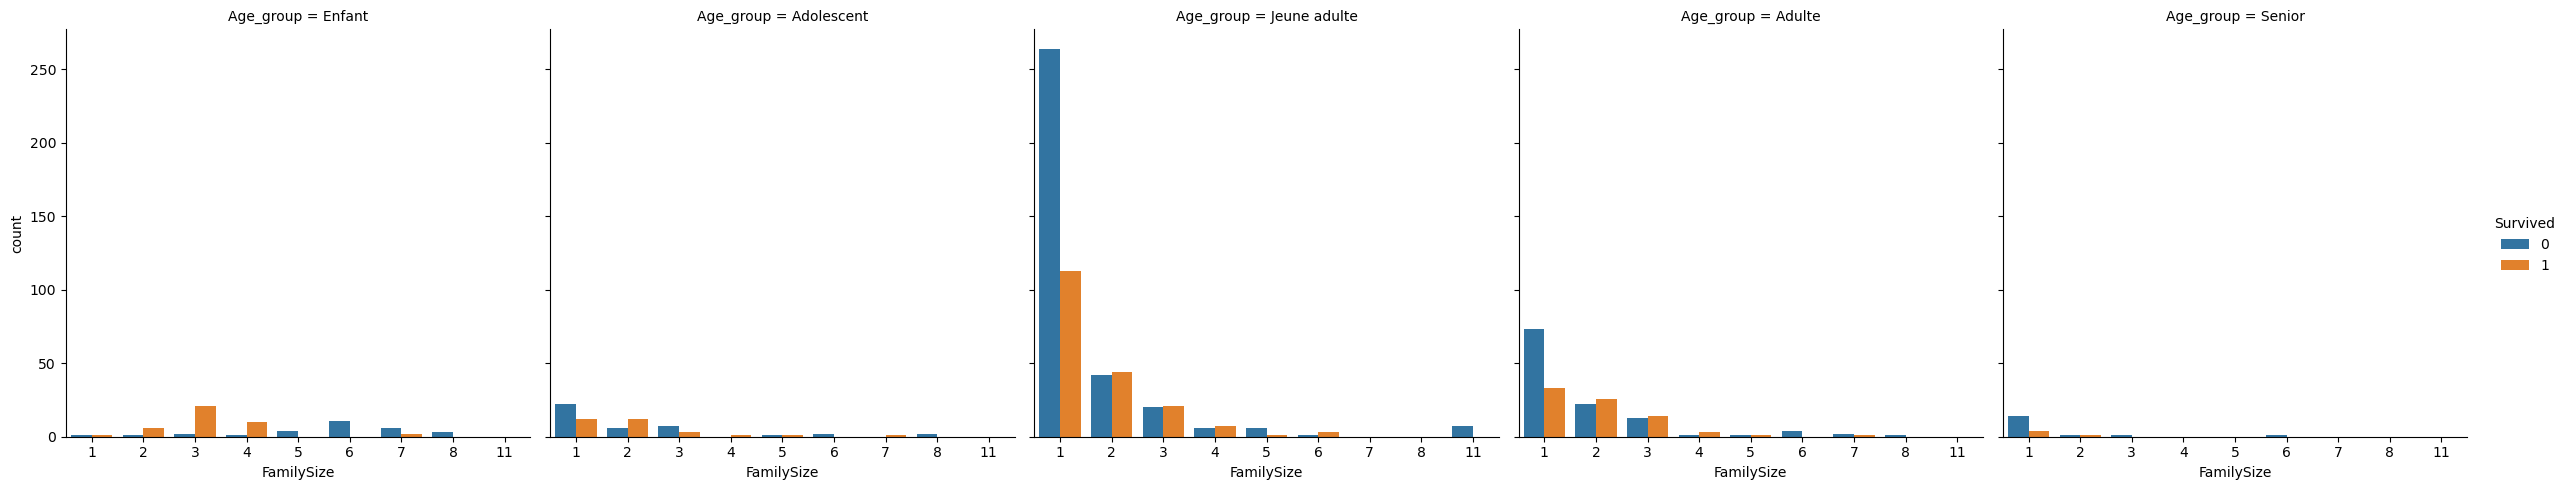

In [34]:
#Taille de famille + Age Group
sns.catplot(x='FamilySize', hue='Survived', col='Age_group', kind='count', data=data)
plt.show()


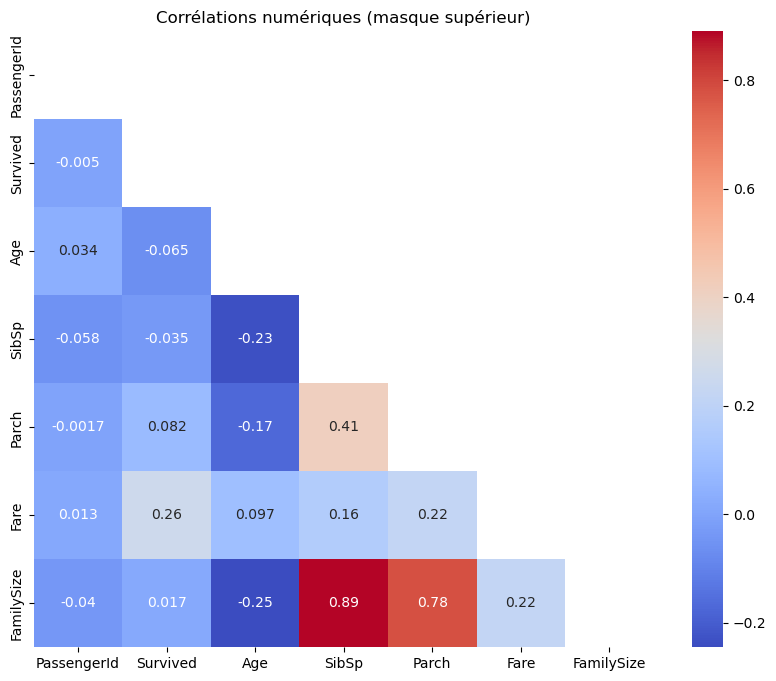

In [35]:
#Corrélation améliorée
numeric_cols = data.select_dtypes(include=np.number)
corr = numeric_cols.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask)
plt.title("Corrélations numériques (masque supérieur)")
plt.show()



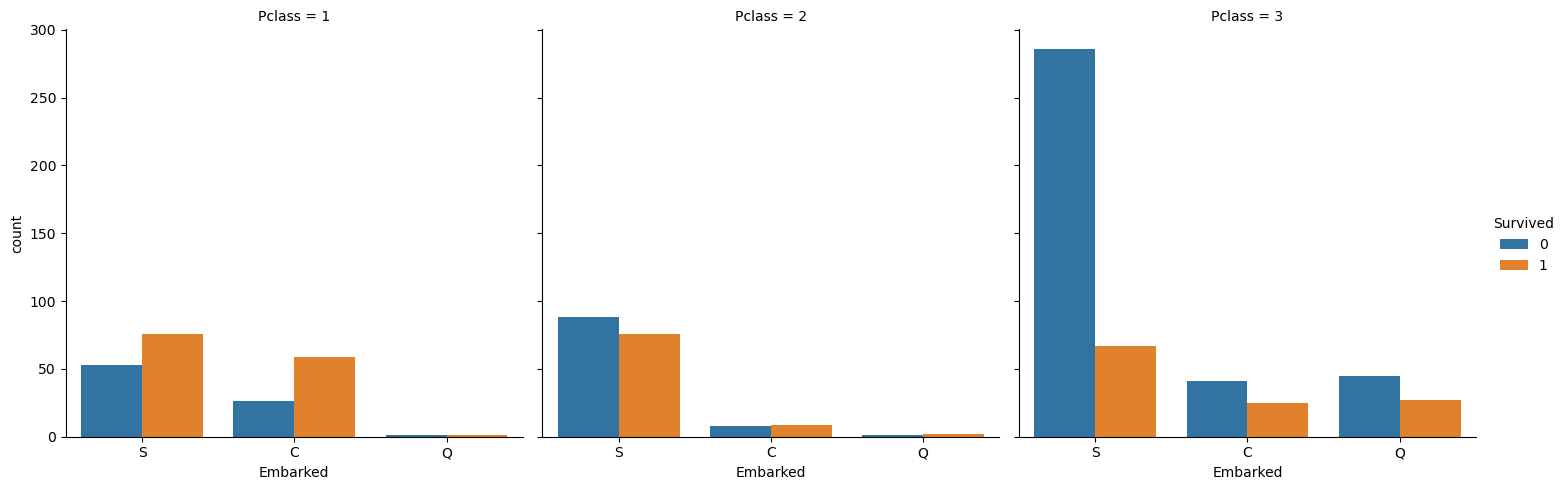

In [36]:
#Port d’embarquement + Classe vs Survie
sns.catplot(x='Embarked', hue='Survived', col='Pclass', kind='count', data=data)
plt.show()


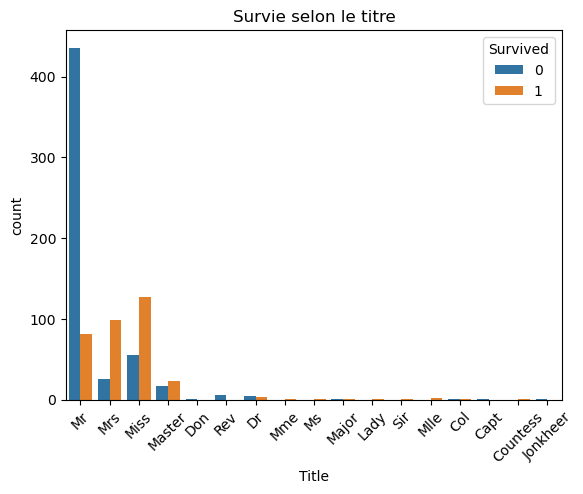

In [37]:
#Titres dans le nom (Mr, Mrs, Miss…)
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
sns.countplot(x='Title', hue='Survived', data=data)
plt.xticks(rotation=45)
plt.title("Survie selon le titre")
plt.show()


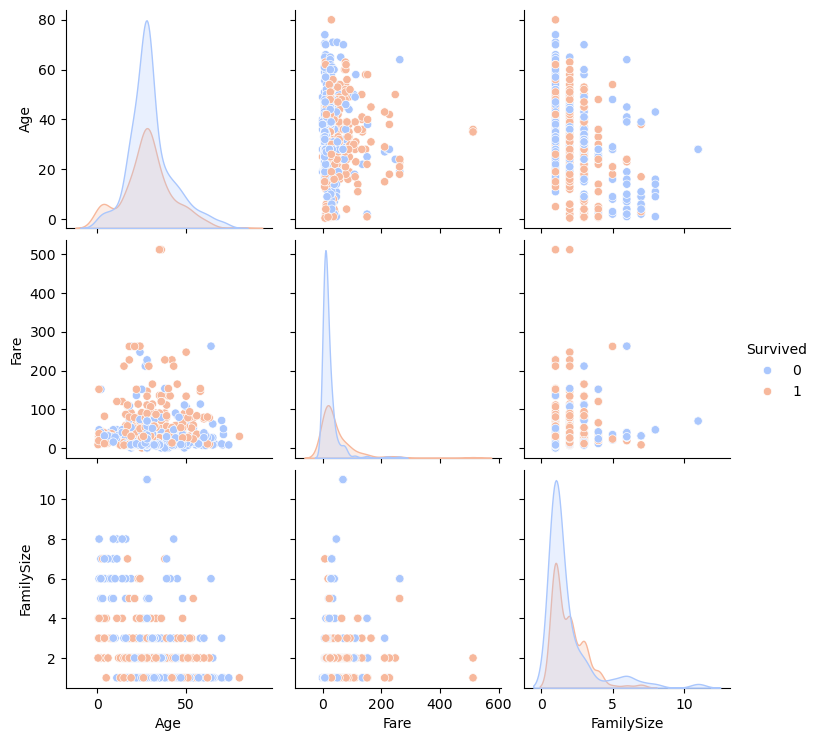

In [38]:
#Relation entre Age, Fare et Survie
sns.pairplot(data, vars=['Age','Fare','FamilySize'], hue='Survived', palette='coolwarm', diag_kind='kde')
plt.show()


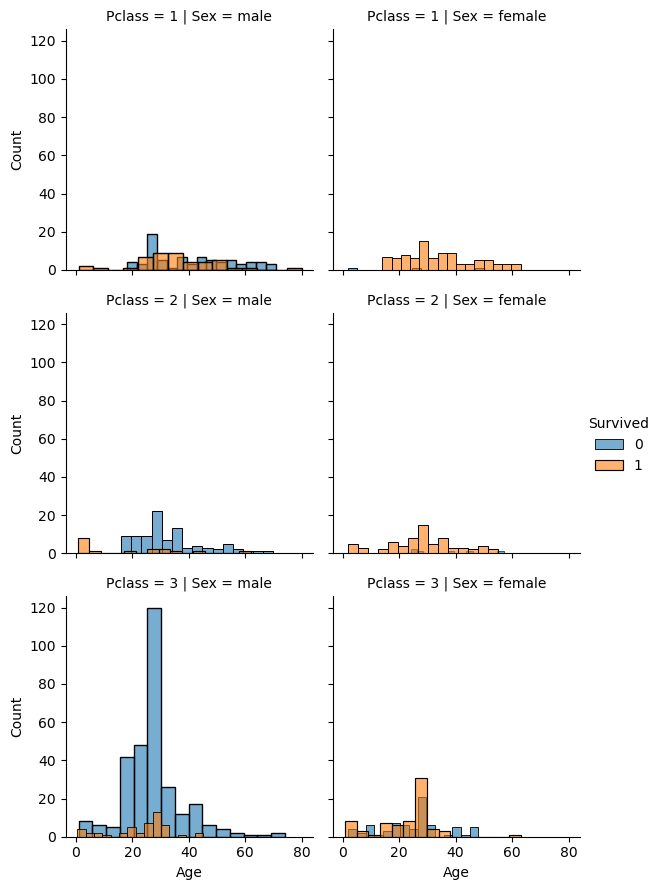

In [39]:
#FacetGrid pour combiner plusieurs variables
g = sns.FacetGrid(data, col='Sex', row='Pclass', hue='Survived')
g.map(sns.histplot, 'Age', bins=15, alpha=0.6)
g.add_legend()
plt.show()


In [42]:
#Études statistique
# Exemple : taux de survie par classe et sexe
survival_rate = data.groupby(['Pclass','Sex'], observed=True)['Survived'].mean()
print(survival_rate)



Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64
